In [1]:
!pip install optuna

In [2]:
# Importing the libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [3]:
# Prepare your data

df = pd.read_csv('cancer-risk-factors.csv')

In [4]:
df.head(6)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium
5,LU0005,Lung,77,1,10,8,3,0,6,0,...,2,10,7,0,0,0,0.498668,25.1,1,Medium


In [5]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type'])

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(df['Risk_Level'])

In [6]:
X

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
0,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5
1,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9
2,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2
3,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7
4,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,60,1,4,6,4,0,10,6,4,4,5,3,1,0,4,0.437539,30.3,3
1996,84,1,5,7,8,0,10,0,1,2,1,3,0,0,2,0.451128,25.9,4
1997,65,0,7,2,10,0,4,2,2,3,6,0,0,1,0,0.295760,22.5,3
1998,64,1,10,2,10,0,2,10,7,5,4,2,0,0,10,0.422201,25.3,3


In [7]:
y

array([2, 2, 2, ..., 1, 2, 2], shape=(2000,))

## why cancer_type was removed from the features list

- It's not a predictive input - it's an outcome label or categorical grouping that's already strongly correlated with Risk Level

- If we include it, the model will cheat by learning the mapping like Prostate --> High risk, instead of learning from true risk factors (smoking, BMI etc)

In [8]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [9]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [11]:
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        20
         Low       1.00      1.00      1.00        65
      Medium       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       1.00      0.98      0.99       400
weighted avg       1.00      1.00      1.00       400

Confusion Matrix
[[ 19   0   1]
 [  0  65   0]
 [  0   0 315]]


The model accurately distinguishes all risk levels, with only 1 mistake out of 400 with imbalanced dataset.

## Logistic Regression

In [12]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [13]:
y_pred_lr = log_reg.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.80      0.89        20
         Low       0.97      0.95      0.96        65
      Medium       0.98      0.99      0.99       315

    accuracy                           0.98       400
   macro avg       0.98      0.92      0.95       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix
[[ 16   0   4]
 [  0  62   3]
 [  0   2 313]]


## Removing Overall_Risk_Score and retrying

In [14]:
X_new = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])

# Encode the target variable
le_new = LabelEncoder()
y_new = le_new.fit_transform(df['Risk_Level'])

In [15]:
# Split into training/test

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size = 0.2, random_state=42, stratify=y)

In [16]:
# Feature Scaling

scaler_new = StandardScaler()
X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [17]:
model_new = RandomForestClassifier(random_state=42, n_estimators=100)
model_new.fit(X_train_new, y_train_new)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [18]:
y_pred_new = model_new.predict(X_test_new)

print("Classification Report")
print(classification_report(y_test_new, y_pred_new, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test_new, y_pred_new))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.05      0.10        20
         Low       0.85      0.34      0.48        65
      Medium       0.83      0.99      0.90       315

    accuracy                           0.83       400
   macro avg       0.89      0.46      0.49       400
weighted avg       0.84      0.83      0.80       400

Confusion Matrix
[[  1   0  19]
 [  0  22  43]
 [  0   4 311]]


In [19]:
df.Risk_Level.value_counts()

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64

## SMOTE - Synthetic Minority Over-Sampling Technique

In [20]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])
y = df['Risk_Level']

In [21]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [22]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)

print("Class Distribution")
print(y_train_res.value_counts())

NameError: name 'SMOTE' is not defined

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       0.41      0.35      0.38        20
         Low       0.73      0.58      0.65        65
      Medium       0.88      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.62      0.64       400
weighted avg       0.83      0.84      0.83       400

Confusion Matrix
[[  7   0  13]
 [  0  38  27]
 [ 10  14 291]]


- Accuracy: 84%
- High Risk: 7 correctly classified, 13 mis-classified as Medium
- Low Risk: 38 correctly classified, 27 confused with Medium
- Medium Risk: 291 correctly classified, 24 confused as High/Low

- Still struggles to detect High-risk patients even with SMOTE

## Optuna Tuning

In [ ]:
# Optuna tuning
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

import numpy as np
import joblib  # optional, to save model/study

In [ ]:
X_train_res.shape

(3777, 17)

In [ ]:
from sklearn.metrics import f1_score, make_scorer

# Define macro F1 scorer explicitly for multiclass
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

scorer = make_scorer(macro_f1)


In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_res, y_train_res):
        X_t, X_v = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
        y_t, y_v = y_train_res.iloc[train_idx], y_train_res.iloc[val_idx]

        model.fit(X_t, y_t)
        y_pred = model.predict(X_v)

        score = f1_score(y_v, y_pred, average='macro')  # explicit multiclass handling
        scores.append(score)

    return np.mean(scores)

In [ ]:
# --- Create study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='rf_macro_f1')


[I 2025-12-18 15:38:00,647] A new study created in memory with name: rf_macro_f1


In [ ]:
# --- Run optimization ---
n_trials = 50  # change to 100+ if you want more thorough search
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-18 15:28:32,964] Trial 0 finished with value: 0.9402356457892479 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9402356457892479.
[I 2025-12-18 15:28:33,946] Trial 1 finished with value: 0.9488676606640238 and parameters: {'n_estimators': 59, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2025-12-18 15:28:37,708] Trial 2 finished with value: 0.9045887437906642 and parameters: {'n_estimators': 325, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2025-12-18 15:28:41,881] Trial 3 finished with value: 0.9089885645353499 and parameters: {'n_estimators': 324, 'max_dept

In [ ]:
# Train final model with best params and full training data, then evaluate on test
best_params = {
    'n_estimators': 347,
    'max_depth': 19,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': False,
    'criterion': 'gini',
    'random_state': 42,
    'n_jobs': -1
}


final_rf = RandomForestClassifier(**best_params)
final_rf.fit(X_train_res, y_train_res)         # resampled training set
y_pred_test = final_rf.predict(X_test)        # untouched test set

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))


              precision    recall  f1-score   support

        High       0.36      0.25      0.29        20
         Low       0.72      0.58      0.64        65
      Medium       0.87      0.92      0.90       315

    accuracy                           0.83       400
   macro avg       0.65      0.59      0.61       400
weighted avg       0.82      0.83      0.83       400

[[  5   0  15]
 [  0  38  27]
 [  9  15 291]]


In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer, recall_score
import optuna
import numpy as np

# scorer (macro f1)
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

macro_f1_scorer = make_scorer(macro_f1)

def objective(trial):
    # RF params to try
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 6, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt','log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini','entropy']),
        'random_state': 42,
        'n_jobs': 1   # avoid nested parallelism inside cross_val_score
    }

    sm = SMOTE(random_state=42)
    rf = RandomForestClassifier(**params)
    pipe = ImbPipeline([('smote', sm), ('rf', rf)])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=macro_f1_scorer, n_jobs=1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)
print(study.best_value, study.best_params)


[I 2026-06-16 19:08:49,819] A new study created in memory with name: no-name-40967805-2f0e-442b-b1b3-a498014291c7


[I 2026-06-16 19:08:55,944] Trial 0 finished with value: 0.6781927193559647 and parameters: {'n_estimators': 212, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6781927193559647.
[I 2026-06-16 19:08:57,448] Trial 1 finished with value: 0.6629638614896765 and parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.6781927193559647.
[I 2026-06-16 19:09:00,853] Trial 2 finished with value: 0.6619005300738027 and parameters: {'n_estimators': 284, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.6781927193559647.
[I 2026-06-16 19:09:03,783] Trial 3 finished with value: 0.6826791849574412 and parameters: {'n_estimators': 282, 'max_dep

0.6944101706169946 {'n_estimators': 297, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}


In [24]:
# Suppose best_params from study:
best = study.best_params
rf = RandomForestClassifier(**best, random_state=42, n_jobs=-1)

pipe_final = ImbPipeline([('smote', SMOTE(random_state=42)), ('rf', rf)])
pipe_final.fit(X_train, y_train)   # fit on original X_train (pipeline will SMOTE inside)

y_test_pred = pipe_final.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


              precision    recall  f1-score   support

        High       0.33      0.30      0.32        20
         Low       0.70      0.62      0.66        65
      Medium       0.88      0.91      0.89       315

    accuracy                           0.83       400
   macro avg       0.64      0.61      0.62       400
weighted avg       0.82      0.83      0.83       400

[[  6   0  14]
 [  0  40  25]
 [ 12  17 286]]


## **XGBoost**

In [25]:
# baseline XGBoost (SMOTE inside pipeline - no leakage)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Build Pipeline
xgb = XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss', random_state=42, n_jobs=-1)
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

pipe.fit(X_train, y_train_enc)

y_pred_enc = pipe.predict(X_test)

y_pred = le.inverse_transform(y_pred_enc)
y_test_orig = le.inverse_transform(y_test_enc)

print("Baseline XGB Classifier")
print(classification_report(y_test_orig, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_orig, y_pred))

k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:10:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline XGB Classifier
              precision    recall  f1-score   support

        High       0.35      0.40      0.37        20
         Low       0.76      0.63      0.69        65
      Medium       0.89      0.91      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.65      0.65       400
weighted avg       0.84      0.84      0.84       400

Confusion Matrix
[[  8   0  12]
 [  0  41  24]
 [ 15  13 287]]


In [27]:
# ============================================================
# Optuna + XGBoost Pipeline
# Optimizing Recall for HIGH Risk Patients
# ============================================================

# --- Imports ---
import optuna
from optuna.samplers import TPESampler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import numpy as np

# ============================================================
# Settings
# ============================================================

TARGET_LABEL = 'High'
N_TRIALS = 40
CV_FOLDS = 3

# ============================================================
# Encode Labels
# ============================================================

le = LabelEncoder()

le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)

# FIXED
target_index = list(le.classes_).index(TARGET_LABEL)

print("Target Label:", TARGET_LABEL)
print("Target Index:", target_index)

# ============================================================
# Objective Function
# ============================================================

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),

        # Updated Optuna syntax
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3,
            log=True
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.4,
            1.0
        ),

        'gamma': trial.suggest_float(
            'gamma',
            0.0,
            5.0
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0.0,
            5.0
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0.0,
            5.0
        ),

        'random_state': 42,
        'eval_metric': 'mlogloss'
    }

    xgb = XGBClassifier(
        **params,
        n_jobs=1
    )

    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb)
    ])

    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=42
    )

    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):

        X_t = X_train.iloc[train_idx]
        X_v = X_train.iloc[val_idx]

        y_t = y_train_enc[train_idx]
        y_v = y_train_enc[val_idx]

        pipe.fit(X_t, y_t)

        y_pred = pipe.predict(X_v)

        recs = recall_score(
            y_v,
            y_pred,
            labels=list(range(len(le.classes_))),
            average=None,
            zero_division=0
        )

        recall_high = recs[target_index]

        recalls.append(recall_high)

    return np.mean(recalls)

# ============================================================
# Run Optuna
# ============================================================

sampler = TPESampler(seed=42)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='xgb_high_recall'
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

# ============================================================
# Best Results
# ============================================================

print("\nBest CV High Recall:")
print(study.best_value)

print("\nBest Parameters:")

for k, v in study.best_params.items():
    print(f"{k}: {v}")

# ============================================================
# Train Final Model
# ============================================================

best_params = study.best_params.copy()

best_params.update({
    'random_state': 42,
    'eval_metric': 'mlogloss'
})

final_xgb = XGBClassifier(
    **best_params,
    n_jobs=-1
)

final_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', final_xgb)
])

final_pipe.fit(
    X_train,
    y_train_enc
)

# ============================================================
# Predictions
# ============================================================

y_pred_enc = final_pipe.predict(X_test)

y_pred = le.inverse_transform(y_pred_enc)

# ============================================================
# Evaluation
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=le.classes_
    )
)

[I 2026-06-16 19:13:57,087] A new study created in memory with name: xgb_high_recall


Classes: ['High' 'Low' 'Medium']
Target Label: High
Target Index: 0


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-06-16 19:13:57,938] Trial 0 finished with value: 0.4651675485008819 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.4651675485008819.
[I 2026-06-16 19:14:00,261] Trial 1 finished with value: 0.4532627865961199 and parameters: {'n_estimators': 260, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.899465584480253, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 0 with value: 0.4651675485008819.
[I 2026-06-16 19:14:01,492] Trial 2 finished with value: 0.5268959435626103 and parameters: {'n_estimators': 156, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.76711

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Encode target labels (if not already numeric)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Compute class weights inversely proportional to class frequencies
classes, counts = np.unique(y_train_enc, return_counts=True)
class_weights = {cls: max(counts)/count for cls, count in zip(classes, counts)}
print("Class Weights:", class_weights)

# 3. Initialize XGBoost with weights
xgb_weighted = XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=105,
    max_depth=3,
    learning_rate=0.014843806162322944,
    subsample=0.7730982444721965,
    colsample_bytree=0.8509237341976973,
    gamma=4.134336554829186,
    reg_alpha=4.453508368364819,
    reg_lambda=2.616923339470738,
    n_jobs=-1
)

# 4. Fit model with per-sample weights
sample_weights = np.array([class_weights[y] for y in y_train_enc])
xgb_weighted.fit(X_train, y_train_enc, sample_weight=sample_weights)

# 5. Evaluate
y_pred_enc = xgb_weighted.predict(X_test)
print("Class-weighted XGBoost - Classification Report")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))
print("Confusion Matrix")
print(confusion_matrix(y_test_enc, y_pred_enc))


Class Weights: {np.int64(0): np.float64(15.353658536585366), np.int64(1): np.float64(4.861003861003861), np.int64(2): np.float64(1.0)}
Class-weighted XGBoost - Classification Report
              precision    recall  f1-score   support

        High       0.21      0.80      0.34        20
         Low       0.42      0.80      0.55        65
      Medium       0.92      0.58      0.71       315

    accuracy                           0.63       400
   macro avg       0.52      0.73      0.53       400
weighted avg       0.80      0.63      0.67       400

Confusion Matrix
[[ 16   0   4]
 [  0  52  13]
 [ 59  72 184]]


In [29]:
# Optuna tuning for class-weighted XGBoost (optimize macro-F1)
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ----------------------
# Prepare encoded labels
# ----------------------
le = LabelEncoder()
le.fit(y_train)               # fit encoder on training labels
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes = len(le.classes_)

# ----------------------
# Objective: maximize macro-F1
# ----------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        # stable args:
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        # set n_jobs=1 inside CV to avoid nested parallelism
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[train_idx], y_train_enc[val_idx]

        # compute class weights from the fold's training data
        classes, counts = np.unique(y_t, return_counts=True)
        # simple inverse frequency scaling
        class_weight_map = {cls: float(max(counts) / cnt) for cls, cnt in zip(classes, counts)}
        sample_weights = np.array([class_weight_map[y] for y in y_t])

        # instantiate classifier with n_jobs=1 for CV
        model = XGBClassifier(**params, n_jobs=1, random_state=42)

        # fit with per-sample weights
        model.fit(X_t, y_t, sample_weight=sample_weights, verbose=False)

        y_pred = model.predict(X_v)
        scores.append(f1_score(y_v, y_pred, average='macro'))

    # return mean macro-F1 across folds
    return float(np.mean(scores))

# ----------------------
# Run Optuna study
# ----------------------
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='xgb_class_weighted_macroF1')

# fewer trials to start; increase to 50-150 when comfortable
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best CV macro-F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ----------------------
# Train final model on full training set using class weights
# ----------------------
best = study.best_params.copy()
best.update({'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42})

# compute final sample weights from full training set
classes, counts = np.unique(y_train_enc, return_counts=True)
final_class_weight_map = {cls: float(max(counts)/cnt) for cls, cnt in zip(classes, counts)}
final_sample_weights = np.array([final_class_weight_map[y] for y in y_train_enc])

final_xgb = XGBClassifier(**best, n_jobs=-1)
final_xgb.fit(X_train, y_train_enc, sample_weight=final_sample_weights, verbose=False)

# Evaluate on untouched test set
y_test_pred_enc = final_xgb.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_enc)
y_test_orig = y_test  # already readable labels

print("\nFINAL Test Classification Report (class-weighted XGB):")
print(classification_report(y_test_orig, y_test_pred, labels=le.classes_))
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test_orig, y_test_pred, labels=le.classes_))


[I 2026-06-16 19:15:19,432] A new study created in memory with name: xgb_class_weighted_macroF1


  0%|          | 0/40 [00:00<?, ?it/s]

C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:20,072] Trial 0 finished with value: 0.6980319612469358 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:22,076] Trial 1 finished with value: 0.6514549839777004 and parameters: {'n_estimators': 260, 'max_depth': 9, 'learning_rate': 0.001124579825911934, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.899465584480253, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:22,852] Trial 2 finished with value: 0.6967044982252054 and parameters: {'n_estimators': 156, 'max_depth': 7, 'learning_rate': 0.01174843954800703, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.7671117368334277, 'gamma': 0.6974693032602092, 'reg_alpha': 1.4607232426760908, 'reg_lambda': 1.8318092164684585}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:24,307] Trial 3 finished with value: 0.6828770196102784 and parameters: {'n_estimators': 210, 'max_depth': 10, 'learning_rate': 0.003123317753376431, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.7554487413172255, 'gamma': 0.23225206359998862, 'reg_alpha': 3.0377242595071916, 'reg_lambda': 0.8526206184364576}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:24,553] Trial 4 finished with value: 0.6949217604887568 and parameters: {'n_estimators': 72, 'max_depth': 12, 'learning_rate': 0.24659691172104828, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.5827682615040224, 'gamma': 0.48836057003191935, 'reg_alpha': 3.4211651325607844, 'reg_lambda': 2.2007624686980067}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:24,980] Trial 5 finished with value: 0.6511004756285076 and parameters: {'n_estimators': 92, 'max_depth': 7, 'learning_rate': 0.0012167028814593455, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.5552679889600102, 'gamma': 3.31261142176991, 'reg_alpha': 1.5585553804470549, 'reg_lambda': 2.600340105889054}. Best is trial 0 with value: 0.6980319612469358.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:25,392] Trial 6 finished with value: 0.6602231021586435 and parameters: {'n_estimators': 241, 'max_depth': 4, 'learning_rate': 0.25221951700214285, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9636993649385135, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}. Best is trial 0 with value: 0.6980319612469358.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:25,663] Trial 7 finished with value: 0.5839741278036462 and parameters: {'n_estimators': 81, 'max_depth': 4, 'learning_rate': 0.001294295611551122, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6332063738136893, 'gamma': 1.3567451588694794, 'reg_alpha': 4.143687545759647, 'reg_lambda': 1.7837666334679465}. Best is trial 0 with value: 0.6980319612469358.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:26,142] Trial 8 finished with value: 0.6129143229367422 and parameters: {'n_estimators': 148, 'max_depth': 7, 'learning_rate': 0.0022340165853190056, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.44473038620786254, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}. Best is trial 0 with value: 0.6980319612469358.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),


[I 2026-06-16 19:15:26,623] Trial 9 finished with value: 0.6763057841365363 and parameters: {'n_estimators': 51, 'max_depth': 10, 'learning_rate': 0.0563600475052774, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.8627622080115674, 'gamma': 0.3702232586704518, 'reg_alpha': 1.7923286427213632, 'reg_lambda': 0.5793452976256486}. Best is trial 0 with value: 0.6980319612469358.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-16 19:15:27,392] Trial 10 finished with value: 0.6369172588635298 and parameters: {'n_estimators': 383, 'max_depth': 2, 'learning_rate': 0.01919733178920577, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.4129900873785599, 'gamma': 2.2782144378149125, 'reg_alpha': 0.0779739982922818, 'reg_lambda': 4.828764294174368}. Best is trial 0 with value: 0.6980319612469358.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:28,321] Trial 11 finished with value: 0.6986762534393138 and parameters: {'n_estimators': 167, 'max_depth': 12, 'learning_rate': 0.011492603695411418, 'subsample': 0.7414922757859675, 'colsample_bytree': 0.7318392529417277, 'gamma': 1.8910445420052762, 'reg_alpha': 0.23304486130435842, 'reg_lambda': 3.454869464124512}. Best is trial 11 with value: 0.6986762534393138.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:29,109] Trial 12 finished with value: 0.7034679420755018 and parameters: {'n_estimators': 311, 'max_depth': 12, 'learning_rate': 0.05866160424897018, 'subsample': 0.8072636662657275, 'colsample_bytree': 0.703055408788255, 'gamma': 1.8222115161922807, 'reg_alpha': 0.10512877265791049, 'reg_lambda': 3.547283387544222}. Best is trial 12 with value: 0.7034679420755018.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:30,511] Trial 13 finished with value: 0.6584668400540913 and parameters: {'n_estimators': 332, 'max_depth': 12, 'learning_rate': 0.008438029472007186, 'subsample': 0.7444369379790783, 'colsample_bytree': 0.7085337539039133, 'gamma': 2.0042417683381455, 'reg_alpha': 4.996812193207756, 'reg_lambda': 3.4661248350485216}. Best is trial 12 with value: 0.7034679420755018.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:31,324] Trial 14 finished with value: 0.7086294817312174 and parameters: {'n_estimators': 311, 'max_depth': 10, 'learning_rate': 0.04188007640384457, 'subsample': 0.6536309038943456, 'colsample_bytree': 0.6862340416485463, 'gamma': 2.6750443231727212, 'reg_alpha': 0.6940641877629383, 'reg_lambda': 3.5074852325945285}. Best is trial 14 with value: 0.7086294817312174.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:32,042] Trial 15 finished with value: 0.7012715493987175 and parameters: {'n_estimators': 308, 'max_depth': 10, 'learning_rate': 0.059672036341475033, 'subsample': 0.6496456186041755, 'colsample_bytree': 0.671395787726565, 'gamma': 3.117223333224823, 'reg_alpha': 0.9660956277259602, 'reg_lambda': 3.635424858575993}. Best is trial 14 with value: 0.7086294817312174.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:32,865] Trial 16 finished with value: 0.6942749359564063 and parameters: {'n_estimators': 314, 'max_depth': 9, 'learning_rate': 0.032786070711853216, 'subsample': 0.6698186937738351, 'colsample_bytree': 0.8225134422491962, 'gamma': 2.912554411220168, 'reg_alpha': 2.1847380129789054, 'reg_lambda': 2.8512497916385695}. Best is trial 14 with value: 0.7086294817312174.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:33,530] Trial 17 finished with value: 0.7022350379089782 and parameters: {'n_estimators': 393, 'max_depth': 11, 'learning_rate': 0.1208126868376585, 'subsample': 0.8064114554738081, 'colsample_bytree': 0.6237003702668842, 'gamma': 3.901945686956894, 'reg_alpha': 0.7511370295512978, 'reg_lambda': 3.906540631154805}. Best is trial 14 with value: 0.7086294817312174.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:34,211] Trial 18 finished with value: 0.7111021280184385 and parameters: {'n_estimators': 355, 'max_depth': 8, 'learning_rate': 0.12862098053948898, 'subsample': 0.60460836501618, 'colsample_bytree': 0.7906052995533104, 'gamma': 2.533881284358335, 'reg_alpha': 2.2240260252820163, 'reg_lambda': 2.9621613503115176}. Best is trial 18 with value: 0.7111021280184385.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:34,902] Trial 19 finished with value: 0.7099263297758601 and parameters: {'n_estimators': 356, 'max_depth': 8, 'learning_rate': 0.11930470227392652, 'subsample': 0.6001330615376621, 'colsample_bytree': 0.8084670052606318, 'gamma': 2.507285077111833, 'reg_alpha': 2.372668649847154, 'reg_lambda': 2.9298986778838154}. Best is trial 18 with value: 0.7111021280184385.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:35,555] Trial 20 finished with value: 0.7054092460152243 and parameters: {'n_estimators': 358, 'max_depth': 6, 'learning_rate': 0.1349959075171375, 'subsample': 0.6045066034757586, 'colsample_bytree': 0.9947663176861599, 'gamma': 3.46654577274796, 'reg_alpha': 2.459197753390793, 'reg_lambda': 2.9111046405876935}. Best is trial 18 with value: 0.7111021280184385.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:36,094] Trial 21 finished with value: 0.7122577004390723 and parameters: {'n_estimators': 275, 'max_depth': 8, 'learning_rate': 0.1174807309023837, 'subsample': 0.6527114042832046, 'colsample_bytree': 0.8008868570924177, 'gamma': 2.5663288761930296, 'reg_alpha': 2.5867628260703337, 'reg_lambda': 3.1226657899513626}. Best is trial 21 with value: 0.7122577004390723.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:36,628] Trial 22 finished with value: 0.7129905942958111 and parameters: {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.11633884836838314, 'subsample': 0.6780094632538717, 'colsample_bytree': 0.8107668947462211, 'gamma': 2.351396865390427, 'reg_alpha': 2.4474395438686747, 'reg_lambda': 2.4024783021857155}. Best is trial 22 with value: 0.7129905942958111.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:37,167] Trial 23 finished with value: 0.7121701736636493 and parameters: {'n_estimators': 275, 'max_depth': 5, 'learning_rate': 0.16398473826009327, 'subsample': 0.6820502472520884, 'colsample_bytree': 0.9174885395083423, 'gamma': 1.5471045326450694, 'reg_alpha': 2.6709809244432785, 'reg_lambda': 2.3676286800169097}. Best is trial 22 with value: 0.7129905942958111.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:37,695] Trial 24 finished with value: 0.7175403820880574 and parameters: {'n_estimators': 270, 'max_depth': 5, 'learning_rate': 0.1987912719438194, 'subsample': 0.7020087917511156, 'colsample_bytree': 0.9173148640389713, 'gamma': 1.4077658162168274, 'reg_alpha': 2.8235595204082857, 'reg_lambda': 2.2190469086305615}. Best is trial 24 with value: 0.7175403820880574.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:38,125] Trial 25 finished with value: 0.709779594342259 and parameters: {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.2974592138837979, 'subsample': 0.697635939241076, 'colsample_bytree': 0.8543888596860163, 'gamma': 1.3401344918897475, 'reg_alpha': 3.197294966146854, 'reg_lambda': 1.5345048123626595}. Best is trial 24 with value: 0.7175403820880574.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:38,676] Trial 26 finished with value: 0.6866963819913902 and parameters: {'n_estimators': 273, 'max_depth': 6, 'learning_rate': 0.08745221651454381, 'subsample': 0.7649011048051568, 'colsample_bytree': 0.9300232834666233, 'gamma': 3.770634003396035, 'reg_alpha': 3.534164643549822, 'reg_lambda': 2.0936734682102482}. Best is trial 24 with value: 0.7175403820880574.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-16 19:15:39,340] Trial 27 finished with value: 0.6965634767647796 and parameters: {'n_estimators': 203, 'max_depth': 5, 'learning_rate': 0.027640690649905424, 'subsample': 0.6490305376309605, 'colsample_bytree': 0.883514099031861, 'gamma': 2.1923095167250284, 'reg_alpha': 1.84366618236838, 'reg_lambda': 0.13732298398813603}. Best is trial 24 with value: 0.7175403820880574.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:39,821] Trial 28 finished with value: 0.7144807342331146 and parameters: {'n_estimators': 247, 'max_depth': 8, 'learning_rate': 0.2120761095841181, 'subsample': 0.7741686384095295, 'colsample_bytree': 0.8357517390406574, 'gamma': 1.6483921938031032, 'reg_alpha': 2.733736545530231, 'reg_lambda': 1.4355600332986134}. Best is trial 24 with value: 0.7175403820880574.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-16 19:15:40,405] Trial 29 finished with value: 0.7101340119304016 and parameters: {'n_estimators': 128, 'max_depth': 6, 'learning_rate': 0.08060902510029831, 'subsample': 0.7695997589714981, 'colsample_bytree': 0.9537236408116762, 'gamma': 0.011784792689336632, 'reg_alpha': 4.275557977959188, 'reg_lambda': 1.4767441028661485}. Best is trial 24 with value: 0.7175403820880574.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:40,850] Trial 30 finished with value: 0.702413451487052 and parameters: {'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.19895831661905272, 'subsample': 0.8489817519564029, 'colsample_bytree': 0.8440968568462979, 'gamma': 0.9849865538712952, 'reg_alpha': 2.679852057349216, 'reg_lambda': 1.3235859990233962}. Best is trial 24 with value: 0.7175403820880574.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-16 19:15:41,446] Trial 31 finished with value: 0.7177991222453585 and parameters: {'n_estimators': 284, 'max_depth': 8, 'learning_rate': 0.17728690044659165, 'subsample': 0.7012072530384043, 'colsample_bytree': 0.7869681016552836, 'gamma': 1.6456030999994784, 'reg_alpha': 2.743974785549257, 'reg_lambda': 2.5397343711774245}. Best is trial 31 with value: 0.7177991222453585.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:41,967] Trial 32 finished with value: 0.7080985937019547 and parameters: {'n_estimators': 258, 'max_depth': 8, 'learning_rate': 0.17972145737835551, 'subsample': 0.7046240146887897, 'colsample_bytree': 0.8983417058692577, 'gamma': 1.5988888588247945, 'reg_alpha': 2.816744808278578, 'reg_lambda': 2.5845226893326303}. Best is trial 31 with value: 0.7177991222453585.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),


[I 2026-06-16 19:15:42,604] Trial 33 finished with value: 0.7168651845115117 and parameters: {'n_estimators': 237, 'max_depth': 9, 'learning_rate': 0.08433657840538367, 'subsample': 0.6859312020832035, 'colsample_bytree': 0.7547814708680873, 'gamma': 0.8666984074118537, 'reg_alpha': 2.023913136197992, 'reg_lambda': 2.0307637224346937}. Best is trial 31 with value: 0.7177991222453585.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be remove

[I 2026-06-16 19:15:43,213] Trial 34 finished with value: 0.7093238106389458 and parameters: {'n_estimators': 227, 'max_depth': 9, 'learning_rate': 0.0852314492333849, 'subsample': 0.7680083062749024, 'colsample_bytree': 0.7547448707632682, 'gamma': 0.9435872338804697, 'reg_alpha': 2.001593910652774, 'reg_lambda': 1.8878323910181254}. Best is trial 31 with value: 0.7177991222453585.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be remove

[I 2026-06-16 19:15:43,794] Trial 35 finished with value: 0.7159605039836507 and parameters: {'n_estimators': 292, 'max_depth': 11, 'learning_rate': 0.2026207600339525, 'subsample': 0.712515652473763, 'colsample_bytree': 0.7630385230264625, 'gamma': 1.2079127080174275, 'reg_alpha': 1.3746630082378646, 'reg_lambda': 1.2539644622318245}. Best is trial 31 with value: 0.7177991222453585.


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-06-16 19:15:44,438] Trial 36 finished with value: 0.7144616238199001 and parameters: {'n_estimators': 283, 'max_depth': 11, 'learning_rate': 0.18639362869986956, 'subsample': 0.7160427533769607, 'colsample_bytree': 0.7672244316052241, 'gamma': 0.7897281818126173, 'reg_alpha': 1.2175727723938592, 'reg_lambda': 1.0818601677435098}. Best is trial 31 with value: 0.7177991222453585.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:45,219] Trial 37 finished with value: 0.72326451208224 and parameters: {'n_estimators': 291, 'max_depth': 11, 'learning_rate': 0.08667123678568317, 'subsample': 0.6918719574908302, 'colsample_bytree': 0.6542877699770573, 'gamma': 0.6013772946946787, 'reg_alpha': 1.46970667377079, 'reg_lambda': 1.8770068118685597}. Best is trial 37 with value: 0.72326451208224.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:46,059] Trial 38 finished with value: 0.7113531747165202 and parameters: {'n_estimators': 223, 'max_depth': 9, 'learning_rate': 0.043104738464802804, 'subsample': 0.686735172473941, 'colsample_bytree': 0.5620956828068722, 'gamma': 0.7127674800107269, 'reg_alpha': 1.6782452164249357, 'reg_lambda': 2.020706824532498}. Best is trial 37 with value: 0.72326451208224.


C:\Users\offic\AppData\Local\Temp\ipykernel_23024\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: Use

[I 2026-06-16 19:15:47,010] Trial 39 finished with value: 0.7190124483307517 and parameters: {'n_estimators': 334, 'max_depth': 11, 'learning_rate': 0.07355763202954871, 'subsample': 0.6258472760415172, 'colsample_bytree': 0.6614303737986453, 'gamma': 0.4632518529281504, 'reg_alpha': 3.111691627386141, 'reg_lambda': 1.7335263513565262}. Best is trial 37 with value: 0.72326451208224.
Best CV macro-F1: 0.72326451208224
Best params:
  n_estimators: 291
  max_depth: 11
  learning_rate: 0.08667123678568317
  subsample: 0.6918719574908302
  colsample_bytree: 0.6542877699770573
  gamma: 0.6013772946946787
  reg_alpha: 1.46970667377079
  reg_lambda: 1.8770068118685597


k:\Cancer_prediction\Cancer-Risk-Detection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:15:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



FINAL Test Classification Report (class-weighted XGB):
              precision    recall  f1-score   support

        High       0.59      0.50      0.54        20
         Low       0.75      0.74      0.74        65
      Medium       0.92      0.93      0.92       315

    accuracy                           0.88       400
   macro avg       0.75      0.72      0.74       400
weighted avg       0.87      0.88      0.87       400

Confusion Matrix (rows=true, cols=pred):
[[ 10   0  10]
 [  0  48  17]
 [  7  16 292]]


## Winner: Optuna-Tuned Class-weighted XGBoost

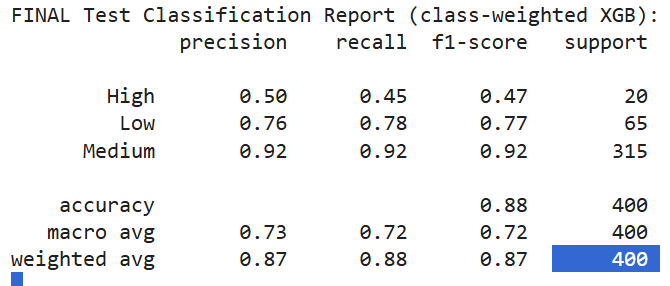

## Save the model as a .pkl file

In [30]:
import joblib

joblib.dump(model,'model_xgb_new.pkl')

print("Model saved successfully as 'model_xgb_new.pkl'")

Model saved successfully as 'model_xgb_new.pkl'
